In [1]:
#Nếu chạy trên Google Colab thì cần kết nối với máy chủ trước
from google.colab import drive #type :ignore
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import os
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
!pip install torchinfo
from torchinfo import summary
%load_ext tensorboard

In [3]:
from keras.datasets import mnist
import cv2

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
(x_train, y_train) , (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
x_train,x_test = torch.from_numpy(x_train).to(device),torch.from_numpy(x_test).to(device)
y_train,y_test = torch.from_numpy(y_train).to(device),torch.from_numpy(y_test).to(device)


In [7]:
x_train = x_train.float() / 255.0
x_test = x_test.float() / 255.0

In [ ]:
class SimpleModel(nn.Module):
    def __init__(self, dropout_rate):
        super(SimpleModel, self).__init__()
        self.dense_1 = nn.Linear(28*28, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.dense_2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dense_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        output = F.log_softmax(self.dense_2(x))
        
        return output

In [9]:
test = SimpleModel(dropout_rate = 0.4).to(device)
summary(test, input_size = (1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleModel                              [1, 10]                   --
├─Linear: 1-1                            [1, 128]                  100,480
├─ReLU: 1-2                              [1, 128]                  --
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41

In [10]:
pip install -U albumentations

In [11]:
import albumentations as A

In [12]:
img_path = '/content/drive/MyDrive/cat.jpg'
img  = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


1. CropAndPad: Cắt hoặc thêm các pixel vào ảnh.

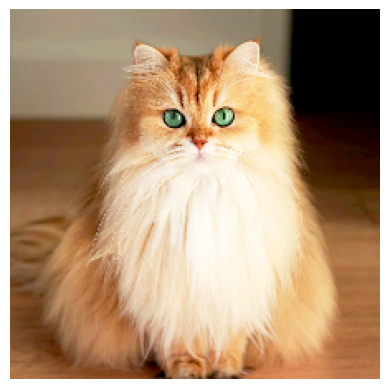

In [13]:
transforms = A.Compose([
    A.RandomResizedCrop(size = (224,224), p = 1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

2. Flip: Flip left-right hoặc Flip up-down một số ảnh trong tập ảnh truyền vào 

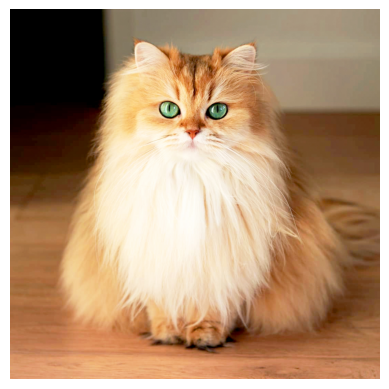

In [14]:
transforms = A.Compose([
    A.HorizontalFlip(p = 1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

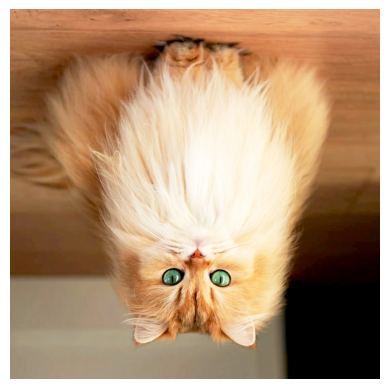

In [15]:
transforms = A.Compose([
    A.VerticalFlip(p = 1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

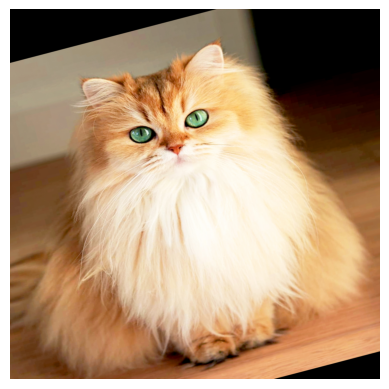

In [16]:
transforms = A.Compose([
    A.Affine(
        scale = (0.5, 1.5),
        translate_percent ={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        rotate = (-15,15)
    )
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

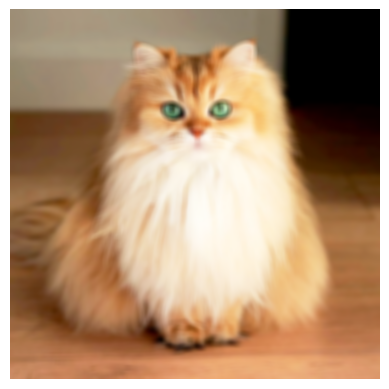

In [17]:
transforms = A.Compose([
    A.Blur(blur_limit = ((11,31)) , p = 1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

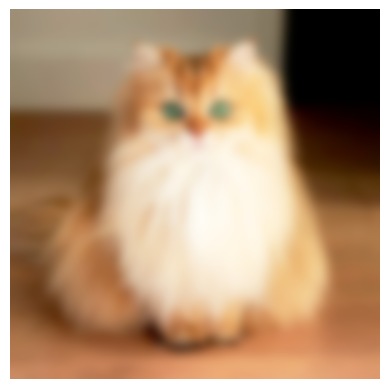

In [18]:
transforms = A.Compose([
    A.GaussianBlur(blur_limit = (0,0) ,sigma_limit = (5,15), p = 1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

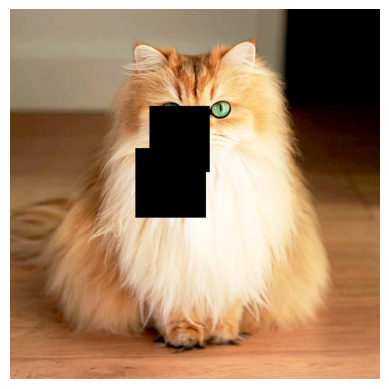

In [19]:
transforms = A.Compose([
    A.CoarseDropout(
        max_holes=8,        
        max_height=32,       
        max_width=32,        
        min_holes=1,          
        p=1.0
    )])
augmented = transforms(image=img_rgb)
img_aug = augmented['image']  
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

### Kết hợp nhiều augmenter

Trong thực tế, có nhiều chiến lược trong việc thực hiện các augmenter khác nhau, thư viện imgaug cũng hỗ trợ một số hàm để thực hiện công việc này:

- Sequential: Áp dụng các augmenter lần lượt theo thứ tự truyền vào:

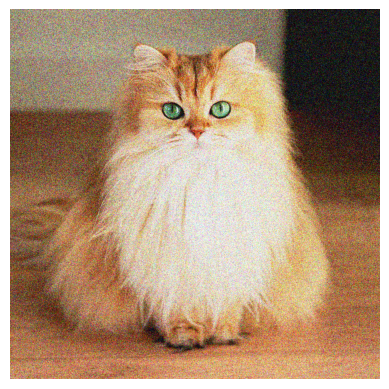

In [20]:
transforms = A.Compose([
    A.Affine(translate_percent ={"x": (-40, 40)}),
    A.GaussNoise(var_limit=(650.25, 650.25), p=1.0)
])
augmented = transforms(image=img_rgb) # Gọi như hàm, dùng (image=...)
img_aug = augmented['image']  # Kết quả trả về là một dict
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

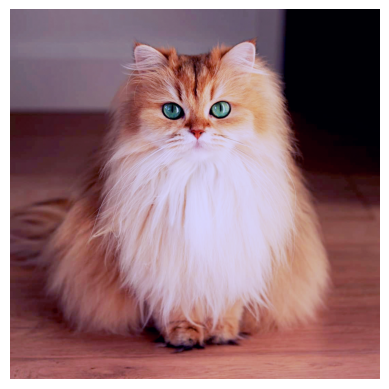

In [21]:
transforms = A.SomeOf([
    A.Rotate(limit=(45, 45), p=1.0),                  
    A.GaussNoise(var_limit=( (0.2*255)**2, (0.2*255)**2 ), p=1.0), 
    A.RGBShift(r_shift_limit=50, g_shift_limit=50, b_shift_limit=50, p=1.0),
    A.Sharpen(alpha=(0.5, 0.5), lightness=(1.0, 1.0), p=1.0)
])
augmented = transforms(image=img_rgb)
img_aug = augmented['image'] 
img_aug = img_aug.astype(np.uint8)
plt.imshow(img_aug)
plt.axis('off')
plt.show()

In [63]:
class Generator(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image ,label = self.images[idx] , self.labels[idx]

        return image, label

In [64]:
training_data = Generator(x_train, y_train)
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)


In [65]:
test_data = Generator(x_test, y_test)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

In [66]:
use_cuda = torch.cuda.is_available()  #GPU cuda
best_loss = float('inf')

model = SimpleModel(dropout_rate = 0.5)

optimizer = torch.optim.Adadelta(model.parameters())

if use_cuda:
    model = torch.nn.parallel.DataParallel(model.cuda())   # , device_ids=[0, 1, 2, 3]
    torch.backends.cudnn.benchmark = True



In [67]:
def train(epoch):
    print('\n ############################# Train phase, Epoch: {} #############################'.format(epoch))
    model.train()
    train_loss = 0

    print('\nLearning rate at this epoch is: ', optimizer.param_groups[0]['lr'], '\n')

    for (batch_idx, target_tuple) in enumerate(train_dataloader):
        if use_cuda:
            target_tuple = [target_tensor.cuda(non_blocking=True) for target_tensor in target_tuple]

        images, labels = target_tuple
        # Convert label to long type pytorch
        labels = torch.tensor(labels,dtype=torch.long)

        optimizer.zero_grad()  # zero the gradient buff
        output_tuple = model(images)

        loss = F.nll_loss(output_tuple, labels).cuda()

        loss.backward()  # retain_graph=True
        optimizer.step()

        train_loss += loss.item()  # loss　　　
        print('########################### Epoch:', epoch, ', --  batch:',  batch_idx, '/', len(train_dataloader), ',   ',
              'Train loss: %.3f, accumulated average loss: %.3f ##############################' % (loss.item(), train_loss / (batch_idx + 1)))

    global best_loss
    train_loss /= len(train_dataloader)
    if train_loss < best_loss:
      noti = 'best_'
      best_loss = train_loss
    else:
      noti = ''
    print('saving...')
    state = {
      'weights': model.module.state_dict(),
      'optimizer_weight': optimizer.state_dict(),
      'train_loss': train_loss,
      'epoch': epoch,
    }
    os.makedirs('checkpoints', exist_ok=True)
    torch.save(state, 'checkpoints/model_' + noti + str(epoch) + '_epoch.pth')



In [68]:
def test(epoch):
    print('\n ############################# Test phase, Epoch: {} #############################'.format(epoch))
    model.eval()
    with torch.no_grad():
        test_loss = 0

        for (batch_idx, target_tuple) in enumerate(test_dataloader):
            if use_cuda:
                target_tuple = [target_tensor.cuda(non_blocking=True) for target_tensor in target_tuple]

            images, labels = target_tuple
            # Convert label to long type pytorch
            labels = torch.tensor(labels,dtype=torch.long)
            output_tuple = model(images)

            loss = F.nll_loss(output_tuple, labels).cuda()

            test_loss += loss.item()  # loss　　　
            print('########################### Epoch:', epoch, ', --  batch:',  batch_idx, '/', len(test_dataloader), ',   ',
                  'Test loss: %.3f, accumulated average loss: %.3f ##############################' % (loss.item(), test_loss / (batch_idx + 1)))



In [62]:
no_epoch = 5
for epoch in range(no_epoch):
    train(epoch)
    test(epoch)


 ############################# Train phase, Epoch: 0 #############################

Learning rate at this epoch is:  1.0 



TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.